# General info
___
This file contains first information about sales and customers.


In [1]:
from working_with_db import *
from make_chart import *
from printmd import *

conn = connect_to_local_postgresql(db_name='postgres', user='jet', password='brains')

In [4]:
period_df = execute_query_to_dataframe(conn, read_sql_file_to_string('general_sql/data_period.sql'))
products_df = execute_query_to_dataframe(conn, read_sql_file_to_string('general_sql/products.sql'))
sales_and_customers_df = execute_query_to_dataframe(conn,
                                                    read_sql_file_to_string('general_sql/sales_and_customers.sql'))

printmd(f"The source file contains data on {sales_and_customers_df['number_of_sales'][0]} sales over {period_df['data_period_years'][0]} years.")
printmd(f"First date: {period_df['first_event_day'][0]}, last date: {period_df['last_event_day'][0]}")
printmd(f"{sales_and_customers_df['number_of_customers'][0]} unique users purchased {len(products_df)} products.")
printmd(f"Median sales per customer: {sales_and_customers_df['median_sales_per_user'][0]}")
printmd(f"Average sales per customer: {sales_and_customers_df['avg_sales_per_users'][0]}")

The source file contains data on 39429 sales over 3 years.

First date: 2018-01-01, last date: 2020-12-31

10462 unique users purchased 13 products.

Median sales per customer: 3.0

Average sales per customer: 3

# Product popularity
___
Let's compare the popularity of products by the number of sales and the number of unique customers.

| product_code   |   number_of_sales |   number_of_customers |
|:---------------|------------------:|----------------------:|
| X              |             10217 |                  3017 |
| A              |              9175 |                  2895 |
| B              |              6160 |                  1869 |
| C              |              4067 |                  1520 |
| D              |              3420 |                  1002 |
| H              |              2127 |                   630 |
| F              |              1187 |                   324 |
| I              |               910 |                   414 |
| L              |               741 |                   226 |
| E              |               509 |                   144 |
| K              |               483 |                   154 |
| G              |               368 |                   123 |
| J              |                65 |                    18 |

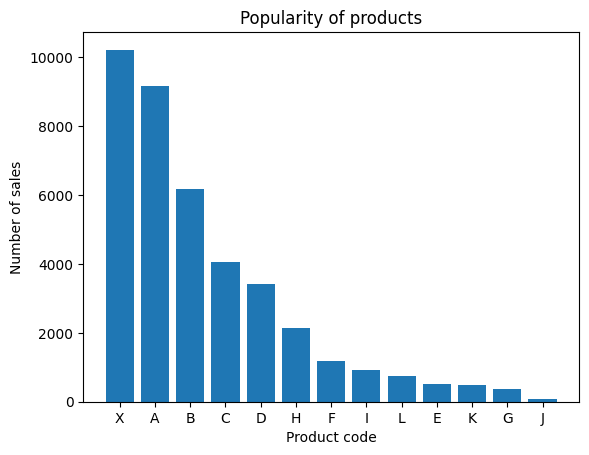


The most popular products are X and A in terms of sales volume and number of customers.

In [6]:
printdf(products_df)

make_chart(dataframe=products_df,
           x_column='product_code',
           y_column='number_of_sales',
           title='Popularity of products',
           chart_type=ChartType.BAR,
           xlabel='Product code',
           ylabel='Number of sales')

printmd(f"\nThe most popular products are {products_df['product_code'][0]} and {products_df['product_code'][1]} in terms of sales volume and number of customers.")


From this report, we have only got basic knowledge about the source data.
<br>Let's continue our research on the metrics.ipynb file